In [1]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score


# Data Visualization
import seaborn as sns
import matplotlib.pyplot as plt

## Importamos los datasets a df


In [2]:
try:
  # Import the datasets into pandas DataFrames
  df = pd.read_csv('oulad_final_procesado.csv')

  print("Datasets imported successfully!")

except FileNotFoundError:
  print("One or more files not found. Check the file paths.")
except pd.errors.ParserError:
  print("Error parsing one or more CSV files. Check file format.")
except Exception as e:
  print(f"An error occurred: {e}")

Datasets imported successfully!


## Visualización de los datos y anñálisis exploratorio

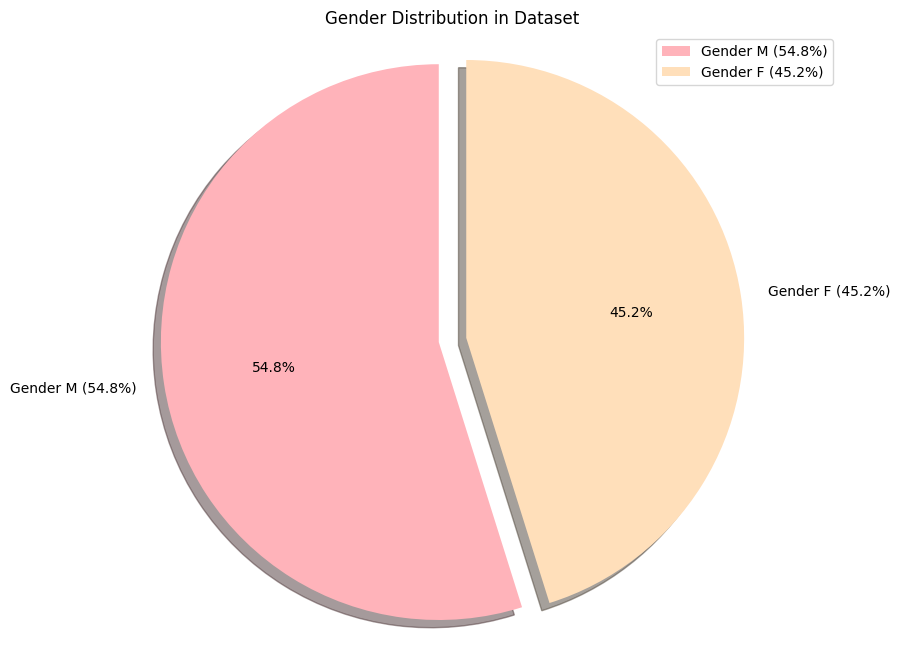

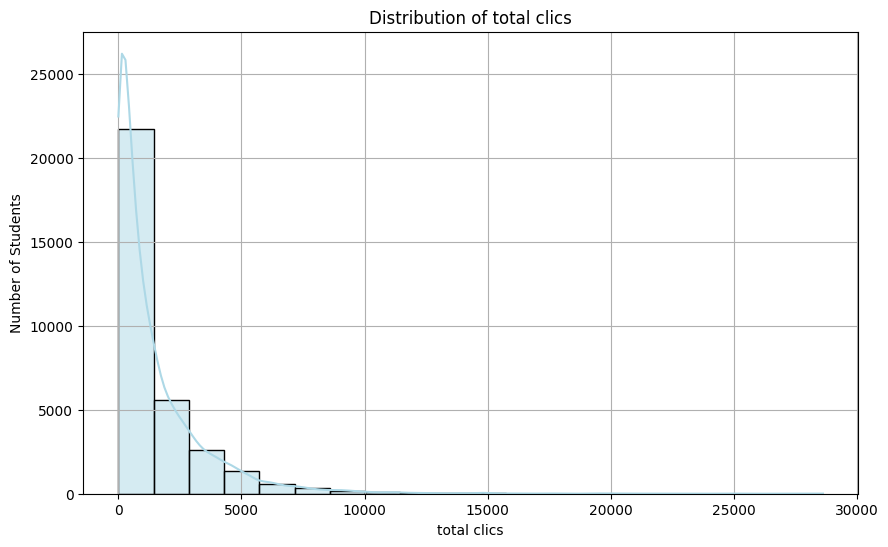

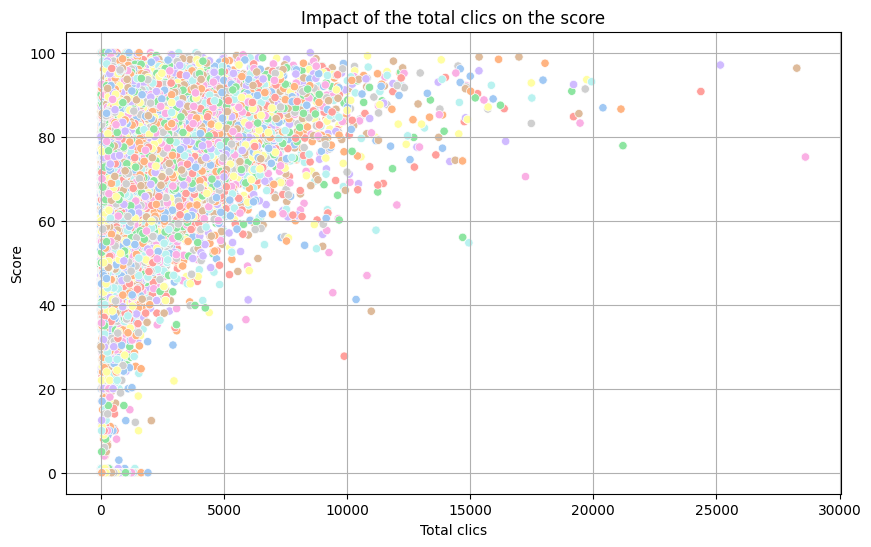

In [3]:
# Gender Distribution Pie Chart
plt.figure(figsize=(10, 8))
gender_counts = df['gender'].value_counts()

# Calculate percentages
total = gender_counts.sum()
percentages = [f'{(count/total)*100:.1f}%' for count in gender_counts]

# Create pie chart with pastel colors
colors = ['#FFB3BA', '#FFDFBA']  # Pastel colors for gender distribution
plt.pie(gender_counts, labels=[f'Gender {i} ({perc})' for i, perc in zip(gender_counts.index, percentages)],
        autopct='%1.1f%%',
        colors=colors,
        explode=[0.05] * len(gender_counts),  
        shadow=True,
        startangle=90)

plt.title('Gender Distribution in Dataset')
plt.axis('equal') 
plt.legend()
plt.show()

# 1. Distribution of Study Hours
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='total_clics', bins=20, kde=True, color='lightblue')
plt.title('Distribution of total clics')
plt.xlabel('total clics')
plt.ylabel('Number of Students')
plt.grid()
plt.show()


# 3. Impact of clics  on Final Result
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='total_clics', y='nota_media_evaluaciones', hue='total_clics', palette='pastel', legend=False)
plt.title('Impact of the total clics on the score')
plt.xlabel('Total clics')
plt.ylabel('Score')
plt.grid()
plt.show()

# Evaluación del modelo con clustering

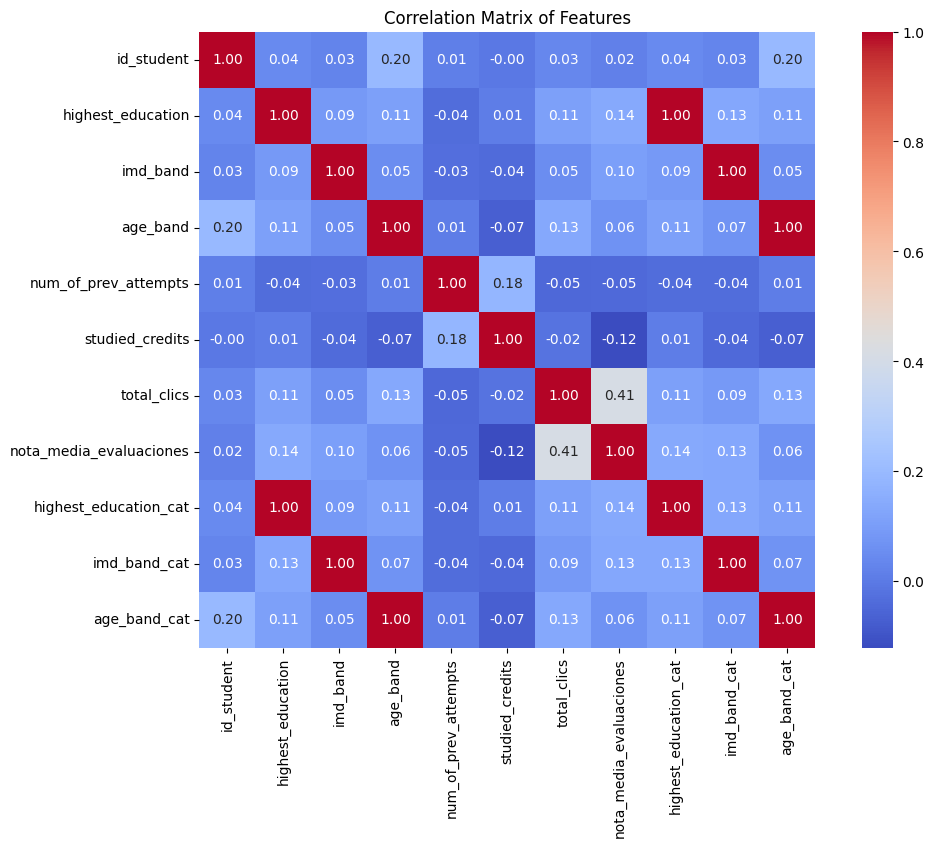

In [4]:
# Step 1: Select all relevant features for correlation analysis
features = df.select_dtypes(include=[np.number])  # Selecting only numeric features

# Step 2: Display the correlation matrix
plt.figure(figsize=(12, 8))
correlation_matrix = features.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Matrix of Features')
plt.show()